In [2]:
library(data.table)
library(Biostrings)

Sys.setlocale("LC_COLLATE", "C")        # garde ton tri byte-order actuel
Sys.setlocale("LC_CTYPE", "en_US.UTF-8") # corrige l'affichage des accents

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, is.unsorted, lapply,
    mapply, match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    rank, rbind, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: 'S4Vectors'


The following objects are masked from 'package:data.table':

    first, second




[1] "C"

[1] "en_US.UTF-8"

In [3]:
sample = '5dbf3203-ce73-41e4-bf9a-32fc856f73f5'
snv_path = "/srv/home/mlef0011/rawdata/PCAWG_data/TCGA/snv_mnv/5dbf3203-ce73-41e4-bf9a-32fc856f73f5.consensus.20160830.somatic.snv_mnv.vcf.gz"
snv_df = fread(snv_path, data.table=F)
snv_df = snv_df[snv_df$FILTER == "." & snv_df$`#CHROM` == 21,]
dim(snv_df)
head(snv_df)

[1] 221   8

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10191,21,10713428,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2553;repeat_masker=ALR/Alpha;t_alt_count=36;t_ref_count=105;Variant_Classification=IGR"
10192,21,10790956,.,A,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2452;repeat_masker=(GAATG)n;t_alt_count=38;t_ref_count=117;Variant_Classification=IGR"
10193,21,10830301,.,A,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2079;repeat_masker=(GAATG)n;t_alt_count=37;t_ref_count=141;Variant_Classification=IGR"
10194,21,10843666,.,A,T,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.1967;repeat_masker=(GAATG)n;t_alt_count=24;t_ref_count=98;signature_N3;Variant_Classification=IGR"
10197,21,10995150,.,C,G,.,.,"Callers=broad,dkfz,muse,sanger;NumCallers=4;VAF=0.1667;t_alt_count=15;t_ref_count=75;Variant_Classification=Intron"
10200,21,11131058,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;repeat_masker=AluSc8;Variant_Classification=IGR"


In [4]:
ref <- readDNAStringSet("/srv/home/mlef0011/rawdata/ref_genome/reference_genome_GRCh37.fa")[1:22]
names(ref) = paste0("chr", 1:22)

In [5]:
k <- 31

# ── Colonnes en vecteurs (l'indexation ligne-à-ligne de data.frame est lente) ──
chr_vec <- as.character(snv_df[[1]])
pos_vec <- as.integer(snv_df[[2]])
alt_vec <- toupper(as.character(snv_df[[5]]))
n <- length(pos_vec)

# ── 1 fenêtre (2k-1) par SNV, extraction groupée par chromosome via Views ──────
windows <- character(n)
for (chrom in unique(chr_vec)) {
    idx <- which(chr_vec == chrom)
    s   <- pos_vec[idx] - k + 1L
    e   <- pos_vec[idx] + k - 1L
    v   <- Views(ref[[paste0("chr", chrom)]], start = s, end = e)
    windows[idx] <- as.character(v)
}
windows <- toupper(windows)

# ── Substituer l'ALT au centre (position k dans la fenêtre 2k-1), vectorisé ────
substr(windows, k, k) <- alt_vec

# ── Générer les k k-mers de chaque fenêtre en un seul substring vectorisé ──────
win_rep   <- rep(windows, each = k)
start_rep <- rep(seq_len(k), times = n)
kmers_all <- substring(win_rep, start_rep, start_rep + k - 1L)

# ── UN SEUL reverseComplement + canonicalisation vectorisée ───────────────────
rc_all    <- as.character(reverseComplement(DNAStringSet(kmers_all)))
canon_all <- pmin(kmers_all, rc_all)

# ── Reshape en liste par SNV (col-major : chaque colonne = un SNV) ────────────
snv_list <- asplit(matrix(canon_all, nrow = k), 2)

In [6]:
# k-mers tumour-specific (dump KMC : kmer <tab> count ; déjà canoniques, ordre byte)
ts_kmers <- fread("/srv/home/mlef0011/VDARK/rawdata/kmer/tumour_specific_chr21_k31.txt",
                  header = FALSE)[[1]]

# k-mers attendus, aplatis et dédupliqués
snv_kmers <- unique(unlist(snv_list, use.names = FALSE))

# ── Recall au niveau k-mer ────────────────────────────────────────────────────
in_ts <- snv_kmers %in% ts_kmers
cat(sprintf("%d / %d k-mers attendus présents (%.1f%%)\n",
            sum(in_ts), length(snv_kmers), 100 * mean(in_ts)))

5478 / 6851 k-mers attendus présents (80.0%)


In [7]:
# ── Recall par SNV (un seul %in%, haché une fois) ─────────────────────────────
dt <- data.table(snv  = rep(seq_along(snv_list), lengths(snv_list)),
                 kmer = unlist(snv_list, use.names = FALSE))
dt[, found := kmer %in% ts_kmers]
per_snv <- dt[, .(n_found = sum(found), n = .N, recall = mean(found)), by = snv]

cat(sprintf("SNVs avec >=1 k-mer présent : %d / %d (%.1f%%)\n",
            sum(per_snv$n_found > 0), nrow(per_snv),
            100 * mean(per_snv$n_found > 0)))
cat(sprintf("Recall k-mer médian (SNVs détectables) : %.0f%%\n",
            100 * median(per_snv$recall[per_snv$n_found > 0])))

SNVs avec >=1 k-mer présent : 212 / 221 (95.9%)
Recall k-mer médian (SNVs détectables) : 100%


SNVs avec >=1 k-mer present : 95.9%


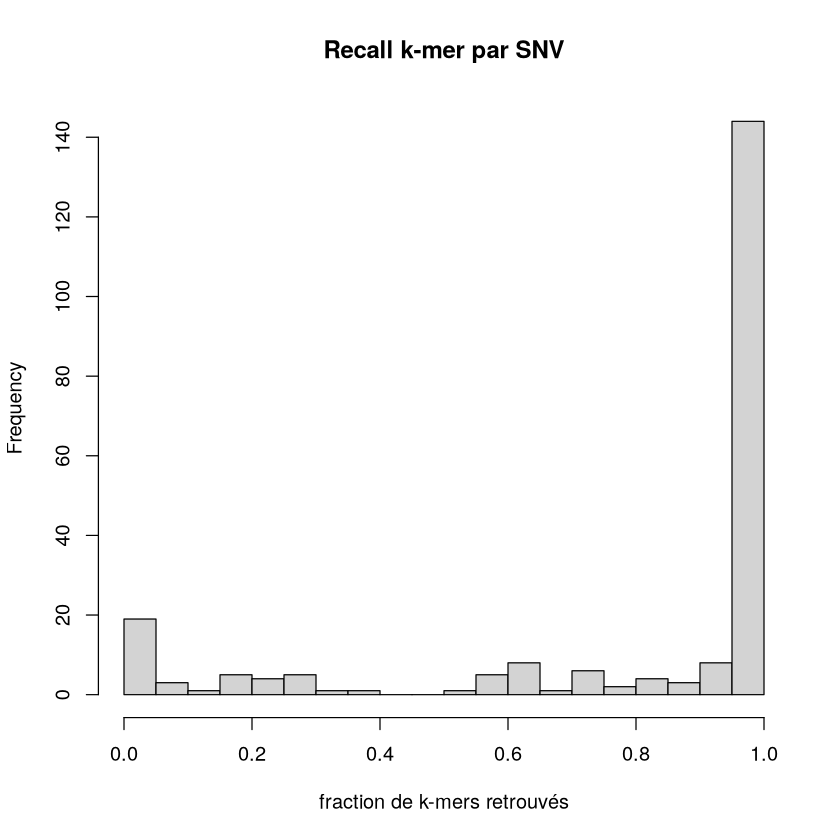

In [8]:
cat(sprintf("SNVs avec >=1 k-mer present : %.1f%%\n",
            100 * mean(per_snv$n_found > 0)))
hist(per_snv$recall, breaks = 32,
     main = "Recall k-mer par SNV", xlab = "fraction de k-mers retrouvés")

In [9]:
per_snv_0 = per_snv[per_snv$n_found == 0,]
snv_df[per_snv_0[["snv"]],]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10200,21,11131058,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;repeat_masker=AluSc8;Variant_Classification=IGR"
10206,21,14935911,.,T,A,.,.,"Callers=broad,muse,sanger;NumCallers=3;VAF=0.1176;repeat_masker=LTR33;t_alt_count=4;t_ref_count=30;Variant_Classification=IGR"
10241,21,18094181,.,T,A,.,.,"Callers=broad,dkfz,muse,sanger;NumCallers=4;VAF=0.0857;repeat_masker=MIR;t_alt_count=3;t_ref_count=32;signature_N3;Variant_Classification=RNA"
10263,21,20009909,.,C,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.0968;repeat_masker=L1PA14;t_alt_count=3;t_ref_count=28;Variant_Classification=lincRNA"
10280,21,21665227,.,C,G,.,.,"Callers=broad,muse,sanger;NumCallers=3;VAF=0.1212;repeat_masker=MER9a2;t_alt_count=4;t_ref_count=29;Variant_Classification=IGR"
10290,21,23218360,.,A,C,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.0882;repeat_masker=L4;t_alt_count=3;t_ref_count=31;Variant_Classification=IGR"
10366,21,37121295,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.0816;repeat_masker=MIRb;t_alt_count=4;t_ref_count=45;Variant_Classification=IGR"
10374,21,38865770,.,A,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.0784;t_alt_count=4;t_ref_count=47;Variant_Classification=Intron"
10433,21,46657999,.,G,A,.,.,"Callers=broad,dkfz,muse,sanger;NumCallers=4;VAF=0.7416;repeat_masker=AluSq;t_alt_count=66;t_ref_count=23;Variant_Classification=lincRNA"


[1] 31

In [15]:
per_snv

snv,n_found,n,recall
<int>,<int>,<int>,<dbl>
1,31,31,1.00000000
2,31,31,1.00000000
3,31,31,1.00000000
4,18,31,0.58064516
5,31,31,1.00000000
6,0,31,0.00000000
7,31,31,1.00000000
8,31,31,1.00000000
9,0,31,0.00000000


In [10]:
per_snv_0[9,]

snv,n_found,n,recall
<int>,<int>,<int>,<dbl>
207,0,31,0


In [11]:
snv_list[[207]]

[1] "CTCTTGTTGCCCAGGCTGGAGTGCAGTGGCA" "GTGCCACTGCACTCCAGCCTGGGCAACAAGA"
 [3] "CTTGTTGCCCAGGCTGGAGTGCAGTGGCACA" "TTGTGCCACTGCACTCCAGCCTGGGCAACAA"
 [5] "ATTGTGCCACTGCACTCCAGCCTGGGCAACA" "GATTGTGCCACTGCACTCCAGCCTGGGCAAC"
 [7] "AGATTGTGCCACTGCACTCCAGCCTGGGCAA" "AAGATTGTGCCACTGCACTCCAGCCTGGGCA"
 [9] "CAAGATTGTGCCACTGCACTCCAGCCTGGGC" "CCAAGATTGTGCCACTGCACTCCAGCCTGGG"
[11] "CCAGGCTGGAGTGCAGTGGCACAATCTTGGC" "AGCCAAGATTGTGCCACTGCACTCCAGCCTG"
[13] "AGGCTGGAGTGCAGTGGCACAATCTTGGCTC" "GGCTGGAGTGCAGTGGCACAATCTTGGCTCA"
[15] "GCTGGAGTGCAGTGGCACAATCTTGGCTCAC" "AGTGAGCCAAGATTGTGCCACTGCACTCCAG"
[17] "CAGTGAGCCAAGATTGTGCCACTGCACTCCA" "GCAGTGAGCCAAGATTGTGCCACTGCACTCC"
[19] "GAGTGCAGTGGCACAATCTTGGCTCACTGCA" "AGTGCAGTGGCACAATCTTGGCTCACTGCAA"
[21] "GTGCAGTGGCACAATCTTGGCTCACTGCAAC" "GGTTGCAGTGAGCCAAGATTGTGCCACTGCA"
[23] "AGGTTGCAGTGAGCCAAGATTGTGCCACTGC" "CAGTGGCACAATCTTGGCTCACTGCAACCTC"
[25] "AGTGGCACAATCTTGGCTCACTGCAACCTCC" "GTGGCACAATCTTGGCTCACTGCAACCTCCA"
[27] "GTGGAGGTTGCAGTGAGCCAAGATTGTGCCA" "GGCACAATCTTGGCTCACTGCAACCTCCACC"
[29] "AGGTGGAGGTTGCAGTGAGCCAAGATTGTGC" "CACAATCTTGGCTCACTGCAACCTCCACCTC"
[31] "ACAATCTTGGCTCACTGCAACCTCCACCTCC"

In [12]:
per_snv_0

snv,n_found,n,recall
<int>,<int>,<int>,<dbl>
6,0,31,0
9,0,31,0
35,0,31,0
56,0,31,0
72,0,31,0
80,0,31,0
150,0,31,0
156,0,31,0
207,0,31,0


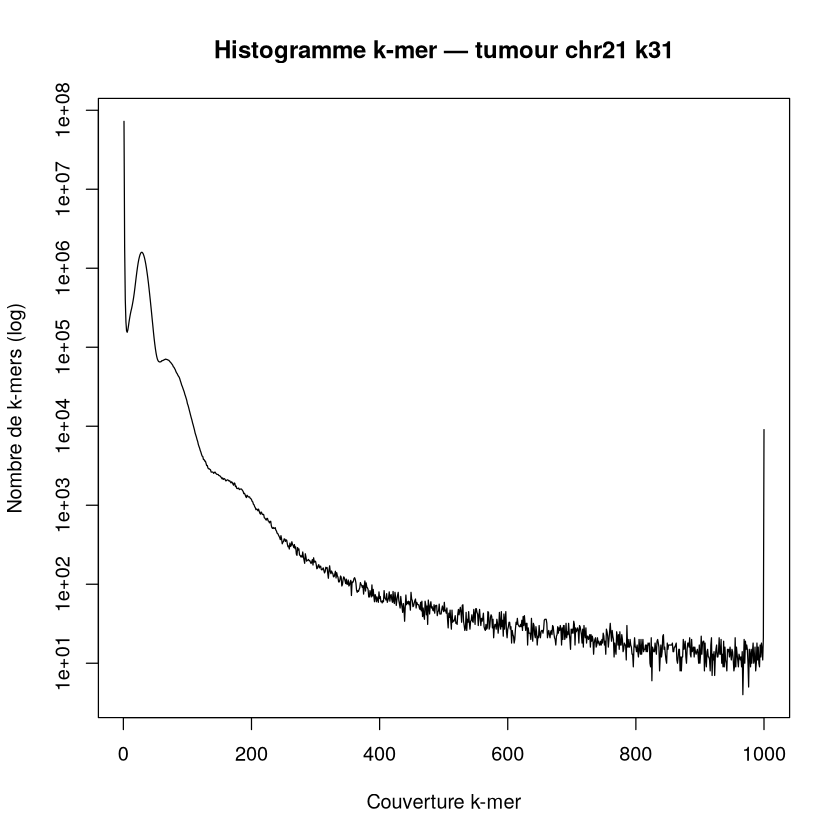

In [13]:
histo_path <- "/srv/home/mlef0011/VDARK/rawdata/kmer/tumour_chr21_k31.histo"

histo <- fread(histo_path, header = FALSE, col.names = c("freq", "count"))
plot(histo$freq, histo$count, type = "l",
     log = "y",
     xlab = "Couverture k-mer", ylab = "Nombre de k-mers (log)",
     main = "Histogramme k-mer — tumour chr21 k31")


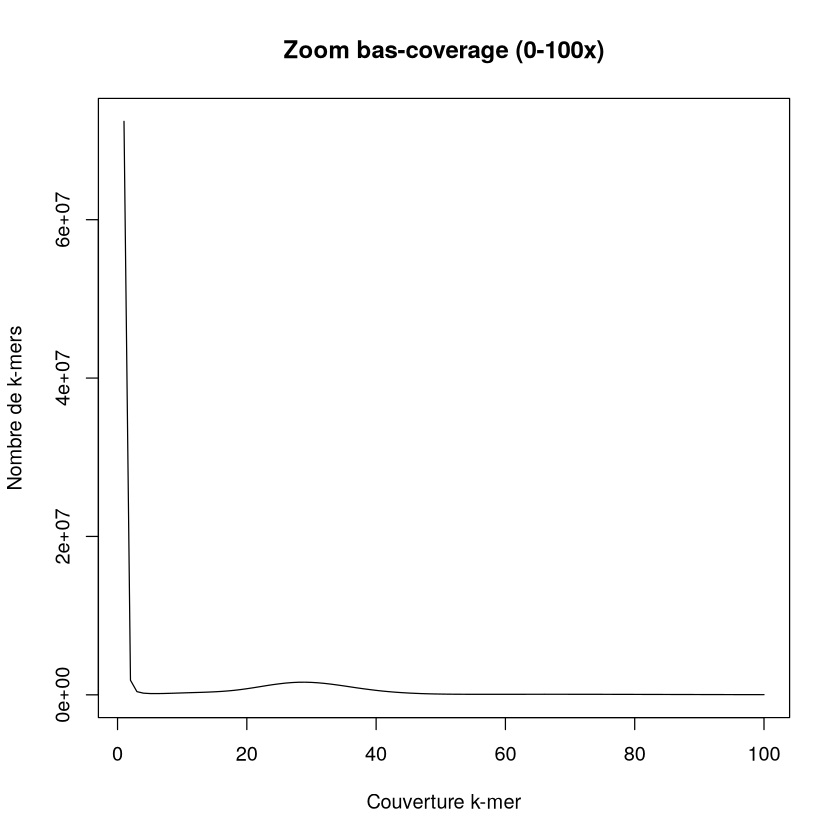

In [14]:
# ── Zoom sur la zone basse couverture (là où se situe le minimum local / MIN_T) ──
plot(histo$freq[histo$freq <= 100], histo$count[histo$freq <= 100], type = "l",
     xlab = "Couverture k-mer", ylab = "Nombre de k-mers",
     main = "Zoom bas-coverage (0-100x)")